# F1 Grid Search — Results Visualisation

Loads the CSV and z-maps produced by `f1_grid_search.py` and shows:
1. **Score panels** — ARI / NMI / Homogeneity / Completeness vs each swept parameter
2. **Active clusters** — how many clusters survive post-MCMC for each initial C
3. **ARI heatmap** — mean ARI for every (n_iter × C) combination
4. **Co-clustering heatmap** — fraction of runs where each pair of races shared a cluster, races in chronological order

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Paths — edit if needed ────────────────────────────────────────────────────
RESULTS_DIR  = Path("results") / "f1_grid"
DATA_DIR     = Path("f1_data")
RANKINGS_DIR = DATA_DIR / "rankings"

METRICS = ["ari", "nmi", "homogeneity", "completeness"]
METRIC_LABELS = {
    "ari":          "ARI",
    "nmi":          "NMI",
    "homogeneity":  "Homogeneity",
    "completeness": "Completeness",
}
PARAMS = ["n_iter", "C", "seed"]

## Load results

In [3]:
# ── Auto-detect latest files ──────────────────────────────────────────────────
csv_path = RESULTS_DIR / "f1_grid_results_latest.csv"
npy_path = RESULTS_DIR / "f1_grid_z_maps_latest.npy"

if not csv_path.exists():
    candidates = sorted(RESULTS_DIR.glob("f1_grid_results_2*.csv"))
    assert candidates, f"No results CSV found in {RESULTS_DIR}. Run f1_grid_search.py first."
    csv_path = candidates[-1]
    print(f"Using: {csv_path}")

if not npy_path.exists():
    candidates = sorted(RESULTS_DIR.glob("f1_grid_z_maps_2*.npy"))
    assert candidates, f"No z_maps .npy found in {RESULTS_DIR}. Run f1_grid_search.py first."
    npy_path = candidates[-1]
    print(f"Using: {npy_path}")

df     = pd.read_csv(csv_path)
z_maps = np.load(npy_path)   # (n_runs, N_races)

print(f"Runs loaded     : {len(df)}")
print(f"z_maps shape    : {z_maps.shape}")
print(f"ARI range       : [{df['ari'].min():.3f}, {df['ari'].max():.3f}]")
print(f"\nTop 5 runs by ARI:")
display(df.sort_values("ari", ascending=False).head()[
    ["n_iter", "C", "seed", "ari", "nmi", "homogeneity", "completeness", "n_active_clusters", "elapsed_s"]
])

Runs loaded     : 45
z_maps shape    : (45, 281)
ARI range       : [0.412, 0.765]

Top 5 runs by ARI:


,n_iter,C,seed,ari,nmi,homogeneity,completeness,n_active_clusters,elapsed_s
4,20000,15,123,0.764943,0.915070,0.883601,0.948864,14,82.5
5,20000,15,777,0.747374,0.895703,0.872556,0.920112,14,149.3
20,50000,15,777,0.742735,0.891952,0.875835,0.908674,14,158.7
34,80000,15,123,0.727567,0.855227,0.845959,0.864702,14,750.3
35,80000,15,777,0.716712,0.875111,0.852350,0.899121,14,685.4


In [4]:
# ── Load race labels in chronological order ───────────────────────────────────
rankings_raw = pd.read_csv(RANKINGS_DIR / "f1_rankings.csv")
race_labels = (
    rankings_raw[["season", "round", "race_name"]]
    .drop_duplicates()
    .sort_values(["season", "round"])
    .apply(lambda r: f"{r.season} R{str(r.round).zfill(2)} {r.race_name}", axis=1)
    .tolist()
)

N_races = z_maps.shape[1]
assert len(race_labels) == N_races, (
    f"Race label count mismatch: {len(race_labels)} labels vs {N_races} in z_maps"
)
print(f"Race labels loaded: {len(race_labels)}  ({race_labels[0]}  …  {race_labels[-1]})")

# Season boundary positions (index of first race per season)
def season_boundaries(labels):
    seen, bounds = set(), []
    for i, lbl in enumerate(labels):
        ssn = lbl.split()[0]
        if ssn not in seen:
            seen.add(ssn)
            bounds.append((i, ssn))
    return bounds

bounds = season_boundaries(race_labels)

Race labels loaded: 281  (2010 R<bound method Series.round of season                     2010
round                         1
race_name    Bahrain Grand Prix
Name: 0, dtype: object> Bahrain Grand Prix  …  2023 R<bound method Series.round of season                       2023
round                          22
race_name    Abu Dhabi Grand Prix
Name: 5933, dtype: object> Abu Dhabi Grand Prix)


## Score panels — metrics vs swept parameters

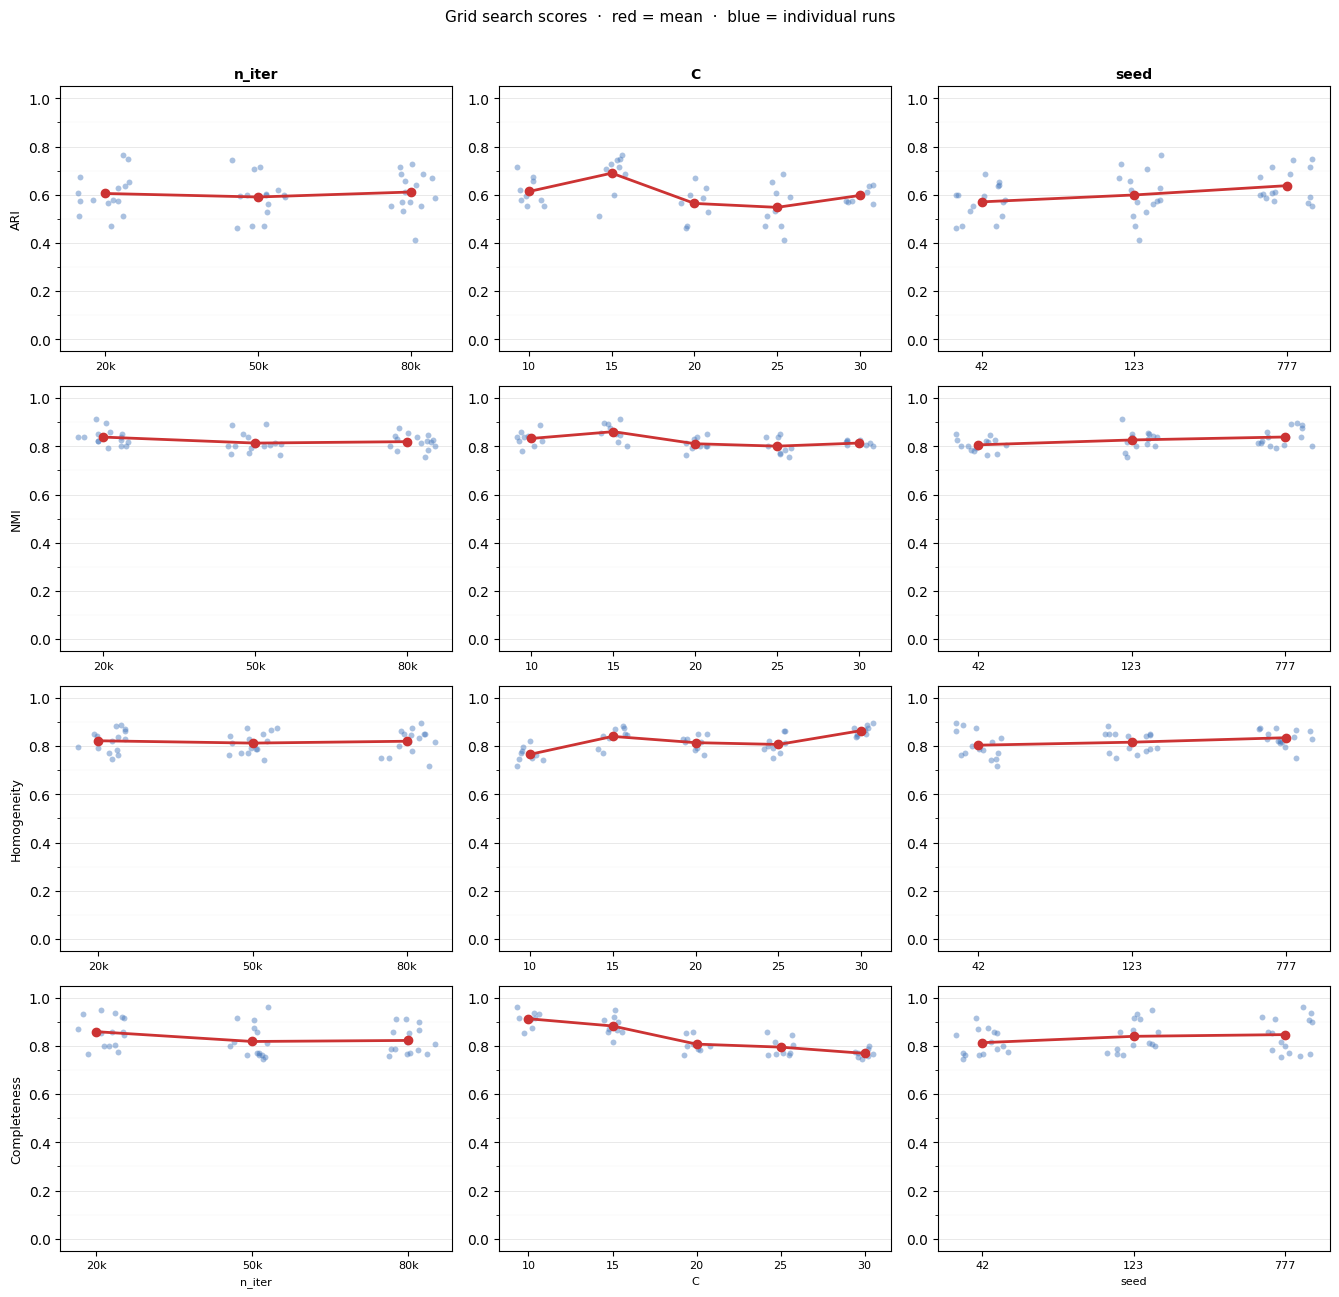

In [5]:
rng_jitter = np.random.default_rng(0)

n_metrics = len(METRICS)
n_params  = len(PARAMS)
fig, axes = plt.subplots(
    n_metrics, n_params,
    figsize=(n_params * 4.5, n_metrics * 3.2),
    squeeze=False,
)

for row, metric in enumerate(METRICS):
    for col, param in enumerate(PARAMS):
        ax = axes[row, col]
        x_vals = sorted(df[param].unique())
        x_pos  = {v: i for i, v in enumerate(x_vals)}

        jitter = rng_jitter.uniform(-0.18, 0.18, size=len(df))
        ax.scatter(
            [x_pos[v] + j for v, j in zip(df[param], jitter)],
            df[metric],
            alpha=0.45, s=18, color="#4477bb", linewidths=0, zorder=2,
        )

        means = df.groupby(param)[metric].mean()
        ax.plot(
            [x_pos[v] for v in means.index],
            means.values,
            color="#cc3333", lw=2.0, marker="o", markersize=6, zorder=3,
        )

        ax.set_xticks(range(len(x_vals)))
        if param == "n_iter":
            ax.set_xticklabels([f"{v//1000}k" for v in x_vals], fontsize=8)
        else:
            ax.set_xticklabels([str(v) for v in x_vals], fontsize=8)

        ax.set_ylim(-0.05, 1.05)
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.1))
        ax.grid(axis="y", which="major", lw=0.5, alpha=0.4)
        ax.grid(axis="y", which="minor", lw=0.25, alpha=0.2)

        if row == 0:
            ax.set_title(param, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
        if row == n_metrics - 1:
            ax.set_xlabel(param, fontsize=8)

fig.suptitle(
    "Grid search scores  ·  red = mean  ·  blue = individual runs",
    fontsize=11, y=1.01,
)
fig.tight_layout()
plt.show()

## Active clusters vs initial C

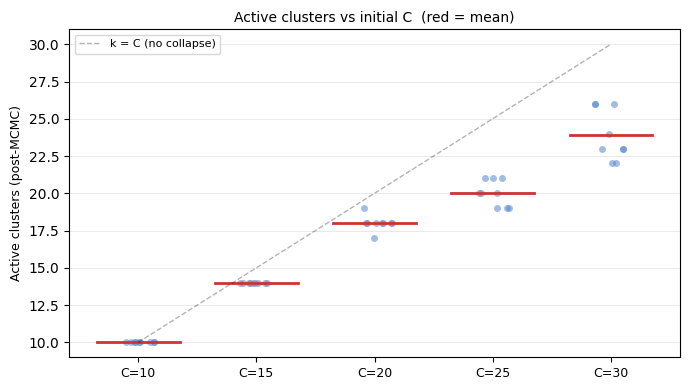

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
C_vals = sorted(df["C"].unique())
rng_j  = np.random.default_rng(1)

for i, c_val in enumerate(C_vals):
    sub = df[df["C"] == c_val]["n_active_clusters"]
    jitter = rng_j.uniform(-0.15, 0.15, size=len(sub))
    ax.scatter(i + jitter, sub, alpha=0.55, s=25, color="#5588cc", linewidths=0)
    ax.plot([i - 0.35, i + 0.35], [sub.mean(), sub.mean()], color="#cc3333", lw=2.0)

ax.set_xticks(range(len(C_vals)))
ax.set_xticklabels([f"C={c}" for c in C_vals], fontsize=9)
ax.set_ylabel("Active clusters (post-MCMC)", fontsize=9)
ax.set_title("Active clusters vs initial C  (red = mean)", fontsize=10)
ax.grid(axis="y", lw=0.5, alpha=0.4)
ax.plot(range(len(C_vals)), C_vals, "k--", alpha=0.3, lw=1, label="k = C (no collapse)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## ARI heatmap — (n_iter × C), averaged over seeds

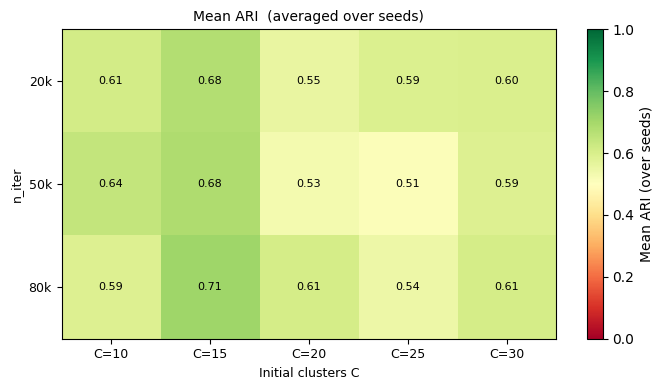

In [7]:
pivot = df.groupby(["n_iter", "C"])["ari"].mean().unstack("C")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Mean ARI (over seeds)")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"C={c}" for c in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v//1000}k" for v in pivot.index], fontsize=9)
ax.set_xlabel("Initial clusters C", fontsize=9)
ax.set_ylabel("n_iter", fontsize=9)
ax.set_title("Mean ARI  (averaged over seeds)", fontsize=10)

for i, row_vals in enumerate(pivot.values):
    for j, val in enumerate(row_vals):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="black" if 0.3 < val < 0.8 else "white")

fig.tight_layout()
plt.show()

## Co-clustering heatmap

Each cell $(i, j)$ shows the fraction of runs where race $i$ and race $j$ were assigned to the same cluster. Races are ordered chronologically — seasonal blocks appear as bright squares along the diagonal.

In [8]:
# ── Build co-clustering matrix (all runs) ─────────────────────────────────────
print(f"Building {N_races}×{N_races} co-clustering matrix over {len(z_maps)} runs…")
co = np.zeros((N_races, N_races), dtype=np.float32)
for z in z_maps:
    co += (z[:, None] == z[None, :]).astype(np.float32)
co /= len(z_maps)
print("Done.")

Building 281×281 co-clustering matrix over 45 runs…
Done.


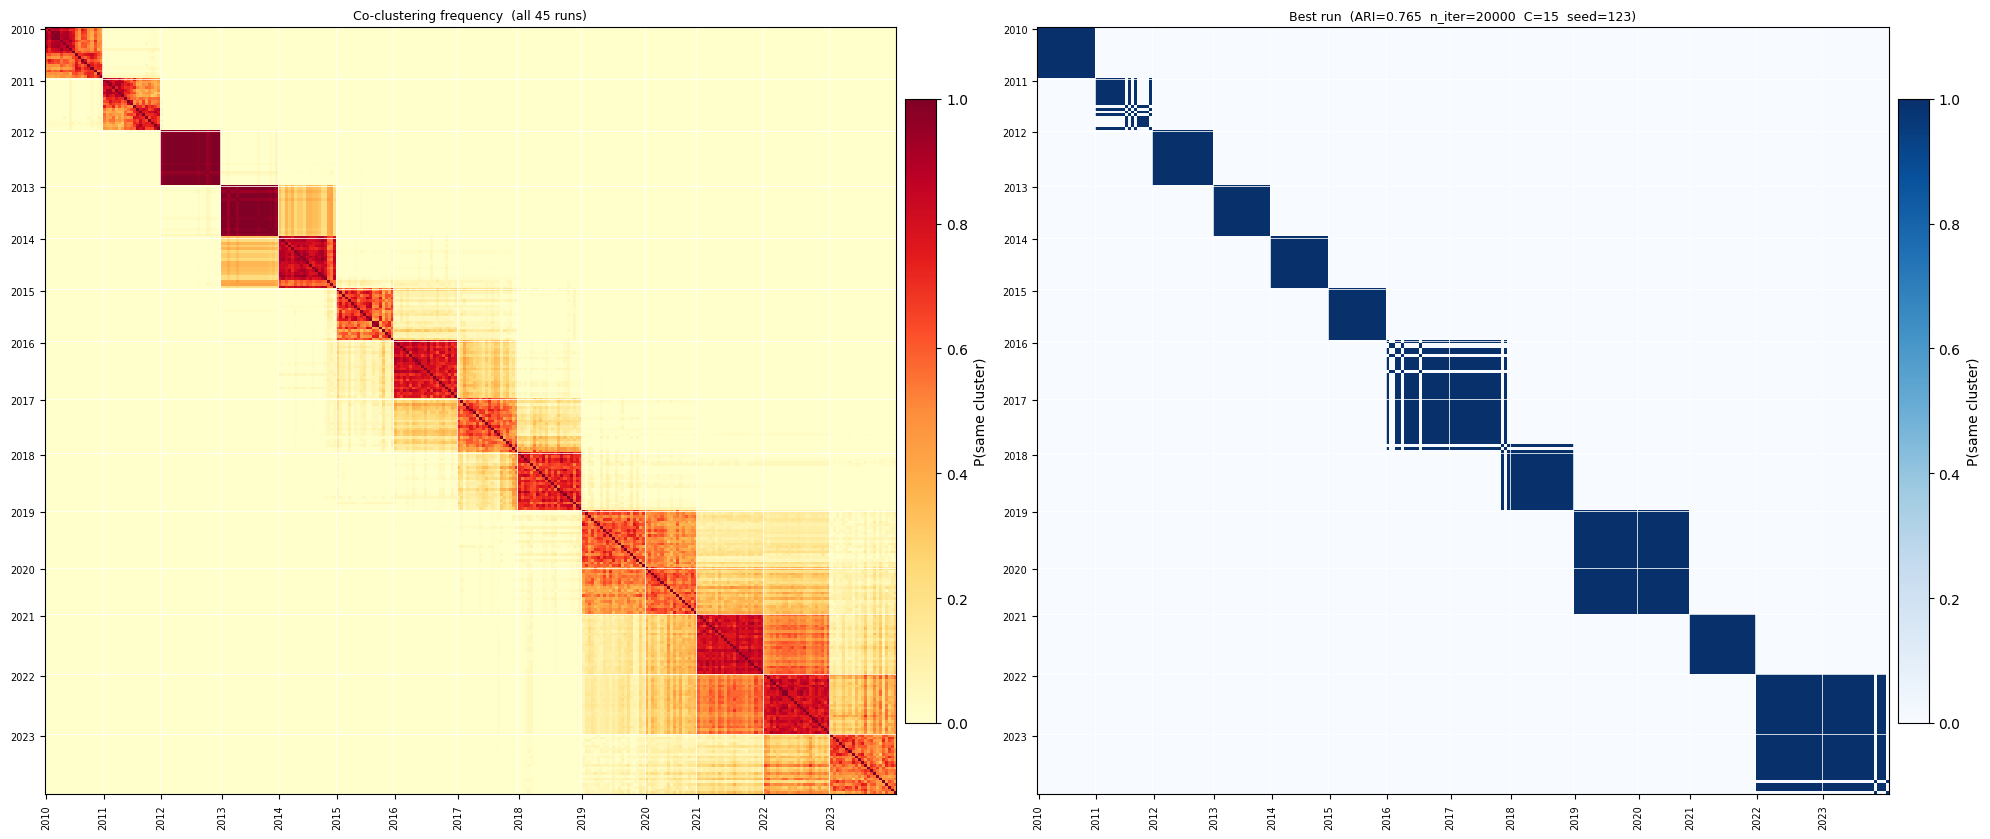

In [9]:
def draw_co_heatmap(ax, co_mat, labels, bounds_, title="", cmap="YlOrRd"):
    N = co_mat.shape[0]
    im = ax.imshow(co_mat, vmin=0, vmax=1, cmap=cmap, aspect="auto",
                   interpolation="nearest", origin="upper")
    plt.colorbar(im, ax=ax, label="P(same cluster)", fraction=0.035, pad=0.01)

    tick_pos  = [b[0] for b in bounds_]
    tick_lbls = [b[1] for b in bounds_]
    for pos, _ in bounds_:
        ax.axhline(pos - 0.5, color="white", lw=0.7, alpha=0.8)
        ax.axvline(pos - 0.5, color="white", lw=0.7, alpha=0.8)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbls, rotation=90, fontsize=7)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(tick_lbls, fontsize=7)
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)
    ax.set_title(title, fontsize=9, pad=6)


# ── Best single run ────────────────────────────────────────────────────────────
best_idx = df["ari"].idxmax()
best_row = df.loc[best_idx]
best_z   = z_maps[best_idx]
co_best  = (best_z[:, None] == best_z[None, :]).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(20, 8.5))

draw_co_heatmap(
    axes[0], co, race_labels, bounds,
    title=f"Co-clustering frequency  (all {len(z_maps)} runs)",
)
draw_co_heatmap(
    axes[1], co_best, race_labels, bounds,
    title=(
        f"Best run  (ARI={best_row['ari']:.3f}  "
        f"n_iter={int(best_row['n_iter'])}  "
        f"C={int(best_row['C'])}  seed={int(best_row['seed'])})"
    ),
    cmap="Blues",
)

fig.tight_layout()
plt.show()

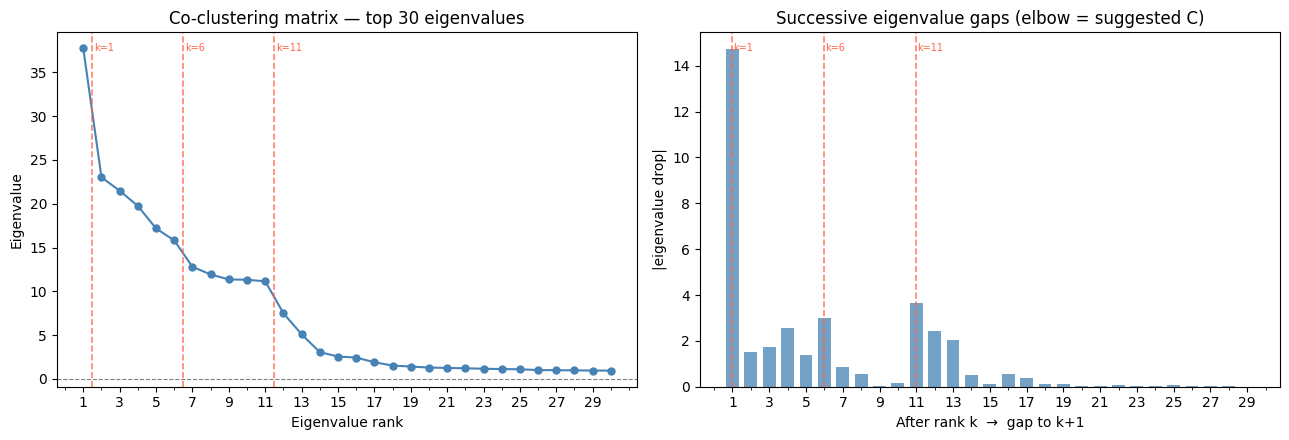

Top-5 largest gaps (rank → rank+1):
  k=1 → k=2:  drop = 14.7194
  k=11 → k=12:  drop = 3.6360
  k=6 → k=7:  drop = 3.0079
  k=4 → k=5:  drop = 2.5659
  k=12 → k=13:  drop = 2.4181


In [11]:

# ── Eigenvalue scree plot of co-clustering matrix ─────────────────────────────
# co is symmetric PSD → use eigh for real, sorted eigenvalues.
# A gap after the k-th eigenvalue suggests k natural clusters.
eigenvalues = np.linalg.eigvalsh(co.astype(np.float64))
eigenvalues = eigenvalues[::-1]          # descending order
n_show = min(30, len(eigenvalues))
idx = np.arange(1, n_show + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# -- Left: full scree plot ----------------------------------------------------
ax1.plot(idx, eigenvalues[:n_show], "o-", markersize=5, lw=1.5, color="steelblue")
ax1.axhline(0, color="grey", lw=0.8, ls="--")
ax1.set_xlabel("Eigenvalue rank")
ax1.set_ylabel("Eigenvalue")
ax1.set_title(f"Co-clustering matrix — top {n_show} eigenvalues")
ax1.set_xticks(idx[::2])
ax1.xaxis.set_minor_locator(mticker.MultipleLocator(1))

# Annotate gaps: highlight the largest drop between consecutive eigenvalues
gaps = np.diff(eigenvalues[:n_show])           # gaps[i] = ev[i+1] - ev[i]  (negative = drop)
top3_drops = np.argsort(gaps)[:3]              # indices of 3 biggest drops
for drop_i in top3_drops:
    k = drop_i + 1                              # cutoff = k clusters
    ax1.axvline(k + 0.5, color="tomato", ls="--", lw=1.2, alpha=0.8)
    ax1.text(k + 0.6, ax1.get_ylim()[1] * 0.97, f"k={k}",
             color="tomato", fontsize=7, va="top")

# -- Right: bar chart of successive gaps (|drop|) — easier to read elbow ------
drop_vals = -gaps                               # positive = eigenvalue fell
ax2.bar(idx[:-1], drop_vals, color="steelblue", alpha=0.75, width=0.7)
ax2.set_xlabel("After rank k  →  gap to k+1")
ax2.set_ylabel("|eigenvalue drop|")
ax2.set_title("Successive eigenvalue gaps (elbow = suggested C)")
ax2.set_xticks(idx[:-1][::2])
ax2.xaxis.set_minor_locator(mticker.MultipleLocator(1))
for drop_i in top3_drops:
    k = drop_i + 1
    ax2.axvline(k, color="tomato", ls="--", lw=1.2, alpha=0.8)
    ax2.text(k + 0.05, ax2.get_ylim()[1] * 0.97, f"k={k}",
             color="tomato", fontsize=7, va="top")

fig.tight_layout()
plt.show()

print("Top-5 largest gaps (rank → rank+1):")
for i in np.argsort(gaps)[:5]:
    print(f"  k={i+1} → k={i+2}:  drop = {-gaps[i]:.4f}")


C:\Users\jonanord\AppData\Local\Temp\ipykernel_38340\1023194326.py:32: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, color=c_col, marker=marker, s=60, linewidths=0.4,


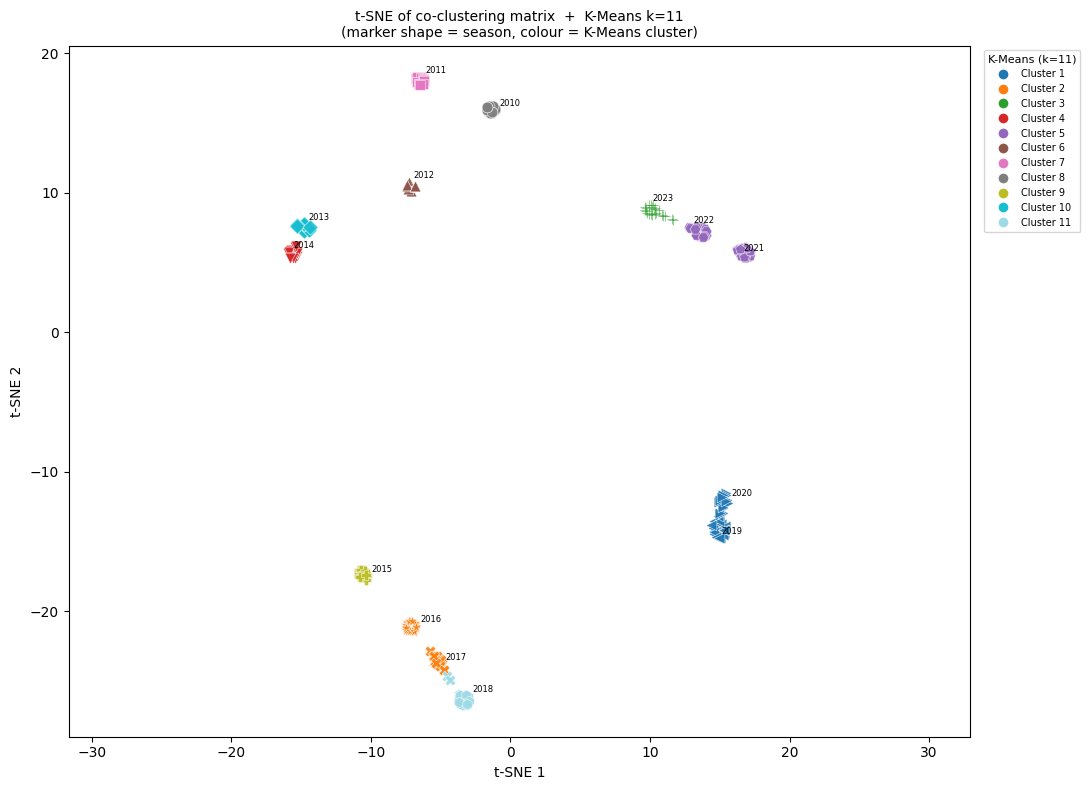


K-Means cluster composition (k=11):
  Cluster  1 ( 38 races): 2019 R<bound method Series.round of season                        2019
round                            1
race_name    Australian Grand Prix
Name: 3873, dtype: object> Australian Grand Prix  …  2020 R<bound method Series.round of season                       2020
round                          17
race_name    Abu Dhabi Grand Prix
Name: 4613, dtype: object> Abu Dhabi Grand Prix
  Cluster  2 ( 39 races): 2016 R<bound method Series.round of season                        2016
round                            1
race_name    Australian Grand Prix
Name: 2591, dtype: object> Australian Grand Prix  …  2017 R<bound method Series.round of season                     2017
round                        18
race_name    Mexican Grand Prix
Name: 3393, dtype: object> Mexican Grand Prix
  Cluster  3 ( 22 races): 2023 R<bound method Series.round of season                     2023
round                         1
race_name    Bahrain Grand Prix
N

In [14]:

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

K_TSNE = 11   # ← change to try different k

# ── t-SNE embedding of the co-clustering matrix ───────────────────────────────
# Each row of `co` is a probability vector over N_races — treat as features.
tsne = TSNE(n_components=2, metric="cosine", perplexity=30,
            random_state=0, init="pca", max_iter=1000)
emb = tsne.fit_transform(co.astype(np.float64))   # (N_races, 2)

# ── K-Means on the raw co-clustering rows (not on t-SNE) ─────────────────────
km = KMeans(n_clusters=K_TSNE, random_state=0, n_init=20)
km_labels = km.fit_predict(co.astype(np.float64))

# ── Season for each race (used for marker shape) ──────────────────────────────
seasons = [lbl.split()[0] for lbl in race_labels]
unique_seasons = sorted(set(seasons))
season_idx = {s: i for i, s in enumerate(unique_seasons)}

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_km = plt.get_cmap("tab20", K_TSNE)
markers = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<", ">",
           "p", "H", "+", "x"]

fig, ax = plt.subplots(figsize=(11, 8))

for i, (x, y) in enumerate(emb):
    c_col  = cmap_km(km_labels[i])
    marker = markers[season_idx[seasons[i]] % len(markers)]
    ax.scatter(x, y, color=c_col, marker=marker, s=60, linewidths=0.4,
               edgecolors="white", zorder=3, alpha=0.9)

# Annotate with season year (avoid overplotting: show label for first race per season)
seen_ann = set()
for i, (x, y) in enumerate(emb):
    ssn = seasons[i]
    if ssn not in seen_ann:
        ax.annotate(ssn, (x, y), fontsize=6, color="black",
                    xytext=(3, 3), textcoords="offset points", zorder=4)
        seen_ann.add(ssn)

# Legend: k-means clusters
km_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap_km(k),
           markersize=8, label=f"Cluster {k+1}")
    for k in range(K_TSNE)
]
ax.legend(handles=km_handles, title=f"K-Means (k={K_TSNE})",
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, title_fontsize=8)

ax.set_title(f"t-SNE of co-clustering matrix  +  K-Means k={K_TSNE}\n"
             f"(marker shape = season, colour = K-Means cluster)", fontsize=10)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()

# ── Print cluster composition ─────────────────────────────────────────────────
print(f"\nK-Means cluster composition (k={K_TSNE}):")
for k in range(K_TSNE):
    members = [race_labels[i] for i in range(N_races) if km_labels[i] == k]
    print(f"  Cluster {k+1:2d} ({len(members):3d} races): "
          f"{members[0]}  …  {members[-1]}")


Best k by silhouette: 12  (sil=0.5964)


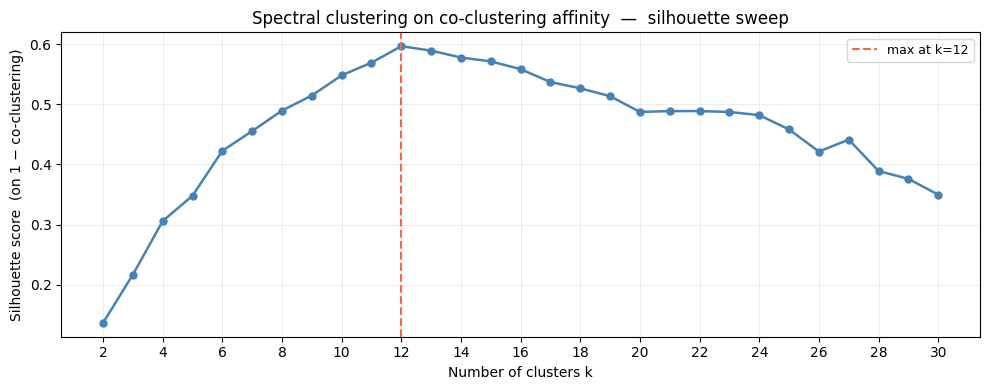

C:\Users\jonanord\AppData\Local\Temp\ipykernel_38340\2799093887.py:59: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, color=cmap_spec(best_spec_labels[i]), marker=marker,


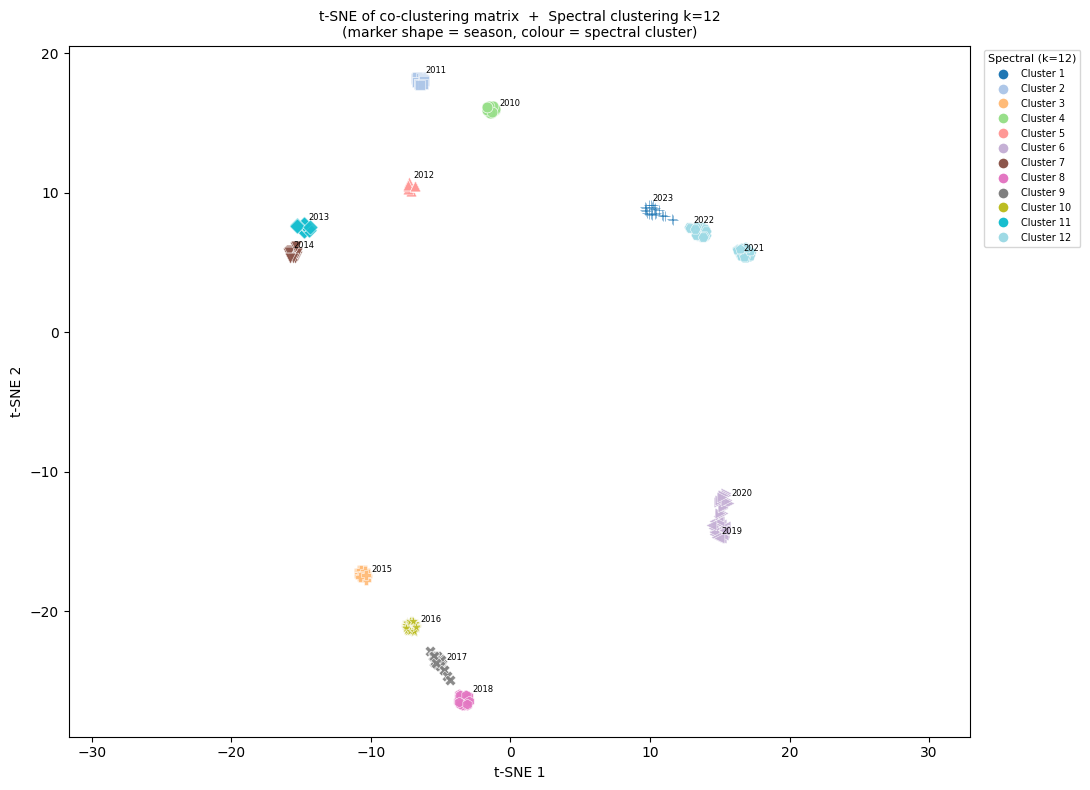


Spectral cluster composition (k=12):
  Cluster  1 ( 22 races): 2023 R<bound method Series.round of season                     2023
round                         1
race_name    Bahrain Grand Prix
Name: 5513, dtype: object> Bahrain Grand Prix  …  2023 R<bound method Series.round of season                       2023
round                          22
race_name    Abu Dhabi Grand Prix
Name: 5933, dtype: object> Abu Dhabi Grand Prix
  Cluster  2 ( 19 races): 2011 R<bound method Series.round of season                        2011
round                            1
race_name    Australian Grand Prix
Name: 456, dtype: object> Australian Grand Prix  …  2011 R<bound method Series.round of season                       2011
round                          19
race_name    Brazilian Grand Prix
Name: 886, dtype: object> Brazilian Grand Prix
  Cluster  3 ( 19 races): 2015 R<bound method Series.round of season                        2015
round                            1
race_name    Australian Grand Pr

In [24]:

from sklearn.cluster import SpectralClustering

# ── Spectral clustering on co-clustering matrix used as affinity ───────────────
# co[i,j] is already a similarity in [0,1], so we use it directly as the
# precomputed affinity matrix.  SpectralClustering builds the normalised graph
# Laplacian, embeds into the top-k eigenvectors, then runs k-means there.
# The eigenvector embedding step is what differentiates this from plain k-means
# on the co-clustering rows.

K_SPEC_RANGE = range(2, 31)   # sweep k from 2 to 30

affinity = co.astype(np.float64)    # (N_races × N_races) similarity matrix

# ── Sweep k and record silhouette on the co-distance (1 - co) ─────────────────
sil_spec = {}
spec_labels_all = {}

for k in K_SPEC_RANGE:
    sc = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=0,
        n_init=10,
    )
    lbl = sc.fit_predict(affinity)
    spec_labels_all[k] = lbl
    if len(np.unique(lbl)) < 2:
        sil_spec[k] = np.nan
        continue
    sil_spec[k] = float(silhouette_score(1.0 - affinity, lbl, metric="precomputed"))

k_arr  = np.array(list(K_SPEC_RANGE))
sil_arr = np.array([sil_spec[k] for k in K_SPEC_RANGE])

best_k_spec = int(k_arr[np.nanargmax(sil_arr)])
print(f"Best k by silhouette: {best_k_spec}  (sil={sil_spec[best_k_spec]:.4f})")

# ── Plot silhouette curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_arr, sil_arr, "o-", color="steelblue", lw=1.8, markersize=5)
ax.axvline(best_k_spec, color="tomato", ls="--", lw=1.5, label=f"max at k={best_k_spec}")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Silhouette score  (on 1 − co-clustering)")
ax.set_title("Spectral clustering on co-clustering affinity  —  silhouette sweep")
ax.legend(fontsize=9)
ax.grid(lw=0.4, alpha=0.4)
ax.set_xticks(k_arr[::2])
fig.tight_layout()
plt.show()

# ── t-SNE coloured by best spectral clustering result ────────────────────────
best_spec_labels = spec_labels_all[best_k_spec]
cmap_spec = plt.get_cmap("tab20", best_k_spec)

fig, ax = plt.subplots(figsize=(11, 8))
for i, (x, y) in enumerate(emb):     # reuse t-SNE embedding from co-clustering cell
    marker = markers[season_idx[seasons[i]] % len(markers)]
    ax.scatter(x, y, color=cmap_spec(best_spec_labels[i]), marker=marker,
               s=60, linewidths=0.4, edgecolors="white", zorder=3, alpha=0.9)

seen_ann = set()
for i, (x, y) in enumerate(emb):
    ssn = seasons[i]
    if ssn not in seen_ann:
        ax.annotate(ssn, (x, y), fontsize=6, color="black",
                    xytext=(3, 3), textcoords="offset points", zorder=4)
        seen_ann.add(ssn)

spec_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap_spec(k),
           markersize=8, label=f"Cluster {k+1}")
    for k in range(best_k_spec)
]
ax.legend(handles=spec_handles, title=f"Spectral (k={best_k_spec})",
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, title_fontsize=8)
ax.set_title(f"t-SNE of co-clustering matrix  +  Spectral clustering k={best_k_spec}\n"
             f"(marker shape = season, colour = spectral cluster)", fontsize=10)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()

# ── Cluster composition ────────────────────────────────────────────────────────
print(f"\nSpectral cluster composition (k={best_k_spec}):")
for k in range(best_k_spec):
    members = [race_labels[i] for i in range(N_races) if best_spec_labels[i] == k]
    print(f"  Cluster {k+1:2d} ({len(members):3d} races): "
          f"{members[0]}  …  {members[-1]}")


In [37]:

import sys, time
sys.path.insert(0, ".")
from model import MixtureRankingModel
from model.dataclasses import ClusterParams

# ── Reproduce the driver index used by f1_grid_search.py ─────────────────────
first_app = (
    rankings_raw.sort_values(["season", "round", "rank"])
    .drop_duplicates("driver_id")
    .set_index("driver_id")[["season", "round"]]
)
drivers = first_app.sort_values(["season", "round"]).index.tolist()
driver_to_idx = {d: i for i, d in enumerate(drivers)}
n_drivers = len(drivers)
print(f"Drivers: {n_drivers}")

# ── Build list of partial rankings ordered by (season, round) ─────────────────
rankings_by_race_idx = []
for _, grp in (
    rankings_raw
    .sort_values(["season", "round", "rank"])
    .groupby(["season", "round"])
):
    rankings_by_race_idx.append(
        [driver_to_idx[d] for d in grp.sort_values("rank")["driver_id"]]
    )
assert len(rankings_by_race_idx) == N_races
print(f"Rankings built: {len(rankings_by_race_idx)} races")

# ── Helper: build Borda-consensus block initialization over all n_drivers ─────
def borda_init_cluster(cluster_rankings, n_items, *, theta=1.0, gamma=1.0, delta=0.5):
    score = np.zeros(n_items)
    count = np.zeros(n_items, dtype=int)
    for r in cluster_rankings:
        m = len(r)
        for pos, item in enumerate(r):
            score[item] += (m - 1 - pos)
            count[item] += 1
    order = list(np.argsort(-score))
    blocks = [[order[i], order[i+1]] for i in range(0, n_items - 1, 2)]
    if n_items % 2 == 1:
        blocks.append([order[-1]])
    return ClusterParams(blocks=blocks, theta=theta, gamma=gamma, delta=delta)


# ── MCMC settings ─────────────────────────────────────────────────────────────
N_ITER   = 10_000
BURN_IN  = N_ITER // 2
SEED     = 0

cluster_map_results = {}
K_SPEC = best_k_spec
print(f"\nRunning {K_SPEC} single-cluster models  (n_iter={N_ITER}, burn_in={BURN_IN})")
print("-" * 70)

for clust_id in range(K_SPEC):
    race_idxs        = [i for i in range(N_races) if best_spec_labels[i] == clust_id]
    cluster_rankings = [rankings_by_race_idx[i] for i in race_idxs]
    seasons_in       = sorted({race_labels[i].split()[0] for i in race_idxs})

    init_cl = borda_init_cluster(cluster_rankings, n_drivers)

    t0 = time.perf_counter()
    model = MixtureRankingModel(
        rankings      = cluster_rankings,
        n_items       = n_drivers,
        init_clusters = [init_cl],
        partial_mode  = "top_k",
        seed          = SEED,
        verbose       = False,
    )
    _, samples = model.run_mcmc(
        n_iter                   = N_ITER,
        burn_in                  = BURN_IN,
        thin                     = 1,
        save_samples             = True,
        save_theta               = True,
        use_py_prior             = False,
        include_order_prior      = False,
        theta_jump               = 5,
        ranking_jump             = 3,
        n_item_moves_per_cluster = 2,
    )
    elapsed = time.perf_counter() - t0
    result  = model.find_map(samples, refine=True, verbose=False)
    cluster_map_results[clust_id] = result

    blocks = result["clusters"][0]["blocks"]
    top5   = [drivers[item] for item in blocks[0]]
    theta  = result["clusters"][0]["theta"]
    print(
        f"  Cluster {clust_id+1:2d}  ({len(race_idxs):3d} races  "
        f"seasons: {', '.join(seasons_in)})  "
        f"K={len(blocks)} blocks  θ={theta:.2f}  top={top5}  [{elapsed:.1f}s]"
    )

print("\nDone.")


Drivers: 77
Rankings built: 281 races

Running 12 single-cluster models  (n_iter=10000, burn_in=5000)
----------------------------------------------------------------------
  Cluster  1  ( 22 races  seasons: 2023)  K=43 blocks  θ=0.35  top=['max_verstappen']  [17.6s]
  Cluster  2  ( 19 races  seasons: 2011)  K=42 blocks  θ=0.35  top=['vettel']  [17.7s]
  Cluster  3  ( 19 races  seasons: 2015)  K=41 blocks  θ=0.38  top=['hamilton']  [16.0s]
  Cluster  4  ( 19 races  seasons: 2010)  K=45 blocks  θ=0.30  top=['alonso']  [15.7s]
  Cluster  5  ( 20 races  seasons: 2012)  K=37 blocks  θ=0.32  top=['vettel']  [16.0s]
  Cluster  6  ( 38 races  seasons: 2019, 2020)  K=39 blocks  θ=0.31  top=['hamilton']  [19.2s]
  Cluster  7  ( 19 races  seasons: 2014)  K=41 blocks  θ=0.38  top=['hamilton']  [15.0s]
  Cluster  8  ( 21 races  seasons: 2018)  K=35 blocks  θ=0.40  top=['hamilton']  [15.0s]
  Cluster  9  ( 20 races  seasons: 2017)  K=37 blocks  θ=0.34  top=['hamilton']  [1894.5s]
  Cluster 10  ( 21

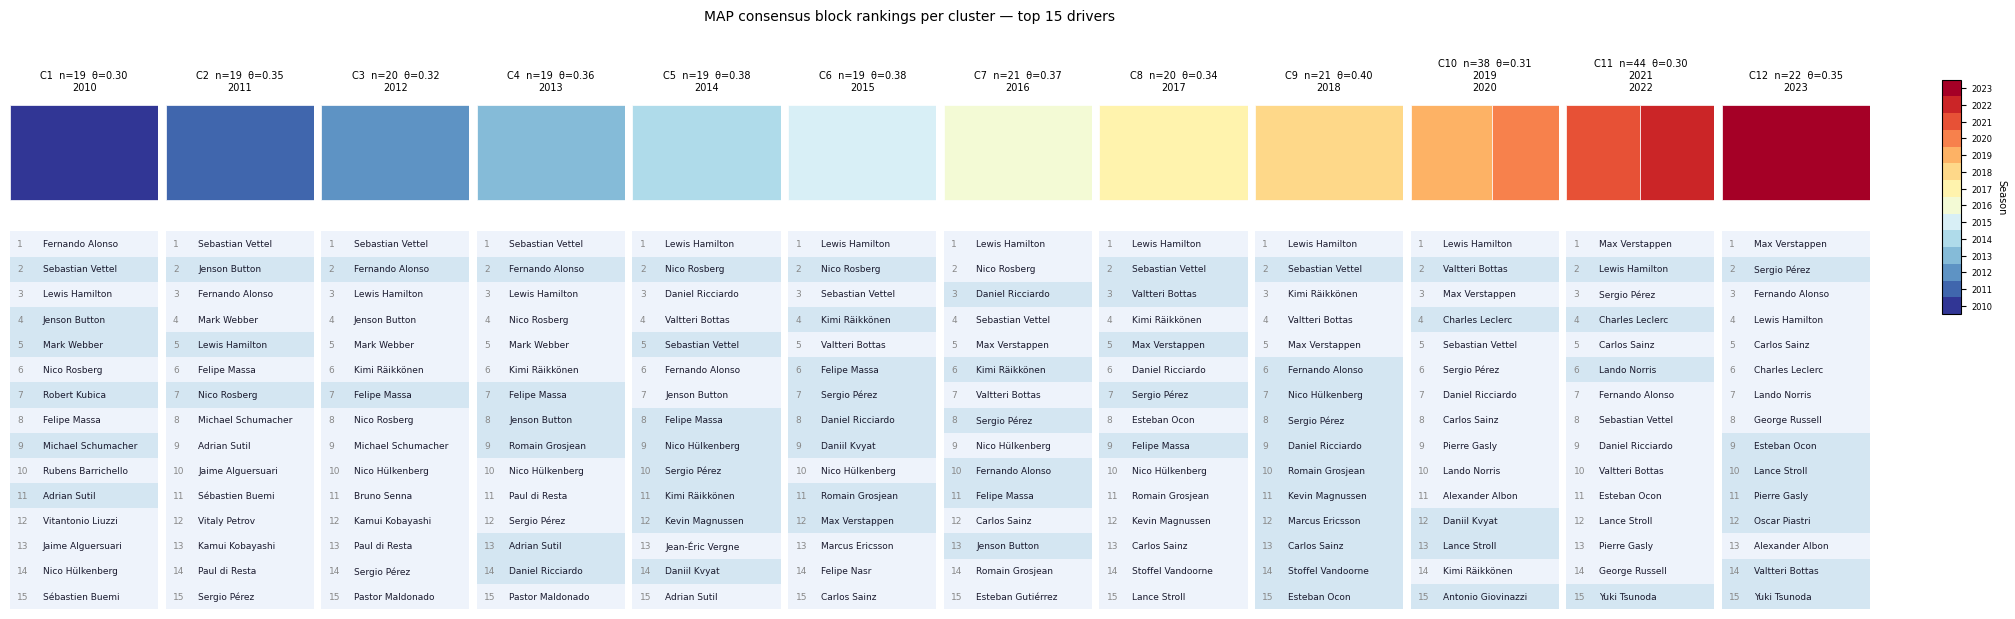

In [38]:

import collections
import matplotlib.patches as mpatches

TOP_K = 15
block_bg = ["#eef3fb", "#d4e6f2"]

# Build driver_name_map from rankings_raw
driver_name_map = (
    rankings_raw[["driver_id", "driver_name"]]
    .drop_duplicates()
    .set_index("driver_id")["driver_name"]
    .to_dict()
)

# All unique seasons ordered chronologically
all_seasons_ordered = sorted(set(lbl.split()[0] for lbl in race_labels), key=int)
n_seasons = len(all_seasons_ordered)
season_to_snum = {s: i for i, s in enumerate(all_seasons_ordered)}
season_cmap = plt.get_cmap("RdYlBu_r", n_seasons)

# Sort clusters chronologically by mean season year
def _mean_season(cid):
    yrs = [int(race_labels[i].split()[0]) for i in range(N_races) if best_spec_labels[i] == cid]
    return np.mean(yrs) if yrs else 9999

sorted_cluster_ids = sorted(range(best_k_spec), key=_mean_season)

ncols = best_k_spec
col_w = 2.0
row_h_top = 1.6
row_h_bot = TOP_K * 0.34

fig, axes_grid = plt.subplots(
    2, ncols,
    figsize=(ncols * col_w, row_h_top + row_h_bot),
    gridspec_kw={"height_ratios": [row_h_top, row_h_bot]},
)
fig.subplots_adjust(wspace=0.05, hspace=0.08)

for col, clust_id in enumerate(sorted_cluster_ids):
    ax_s = axes_grid[0, col]
    ax_r = axes_grid[1, col]

    # ── Season stacked bar ────────────────────────────────────────────────────
    race_idxs_c = [i for i in range(N_races) if best_spec_labels[i] == clust_id]
    n_in = len(race_idxs_c)
    ssn_counts = collections.Counter(race_labels[i].split()[0] for i in race_idxs_c)
    ssns_present = sorted(ssn_counts.keys(), key=int)

    left = 0
    for ssn in ssns_present:
        cnt = ssn_counts[ssn]
        s_norm = season_to_snum[ssn] / max(n_seasons - 1, 1)
        ax_s.barh(
            0, cnt, left=left,
            color=season_cmap(s_norm),
            edgecolor="white", linewidth=0.5, height=0.8,
        )
        left += cnt

    theta_val = cluster_map_results[clust_id]["clusters"][0]["theta"]
    ssns_str = "\n".join(ssns_present) if len(ssns_present) <= 3 else "\n".join(ssns_present[:2]) + f"\n+{len(ssns_present)-2}"
    ax_s.set_xlim(0, n_in)
    ax_s.set_ylim(-0.5, 0.5)
    ax_s.axis("off")
    ax_s.set_title(
        f"C{col+1}  n={n_in}  θ={theta_val:.2f}\n{ssns_str}",
        fontsize=7, pad=2, linespacing=1.25,
    )

    # ── Driver list with alternating block backgrounds ────────────────────────
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(0, TOP_K)
    ax_r.axis("off")

    blocks_hat = cluster_map_results[clust_id]["clusters"][0]["blocks"]
    rank = 0
    for b_idx, block in enumerate(blocks_hat):
        if rank >= TOP_K:
            break
        bg = block_bg[b_idx % 2]
        for driver_idx in block:
            if rank >= TOP_K:
                break
            y0 = TOP_K - rank - 1
            y_mid = y0 + 0.5
            ax_r.add_patch(mpatches.Rectangle(
                (0, y0), 1, 1,
                facecolor=bg, edgecolor="none", zorder=0,
            ))
            ax_r.text(0.05, y_mid, str(rank + 1),
                      fontsize=6.5, color="#888888", ha="left", va="center", zorder=1)
            driver_id = drivers[driver_idx]
            full_name = driver_name_map.get(driver_id, driver_id)
            ax_r.text(0.22, y_mid, full_name,
                      fontsize=6.5, color="#1a1a2e", ha="left", va="center", zorder=1)
            rank += 1

# ── Season colourbar ──────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=season_cmap,
    norm=plt.Normalize(
        vmin=int(all_seasons_ordered[0]) - 0.5,
        vmax=int(all_seasons_ordered[-1]) + 0.5,
    ),
)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.55, 0.008, 0.35])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=[int(s) for s in all_seasons_ordered])
cbar.ax.set_yticklabels(all_seasons_ordered, fontsize=6)
cbar.ax.set_ylabel("Season", fontsize=7, rotation=270, labelpad=10)

fig.suptitle("MAP consensus block rankings per cluster — top 15 drivers", fontsize=10, y=1.005)
plt.show()


In [44]:

# ── Stability check: full 12-cluster model initialised from consensus ─────────
# Build one ClusterParams per spectral cluster from the MAP results, assign
# init_z from best_spec_labels, then run the full mixture model with short
# burn-in (already near the mode) and no annealing.
import time as _time

N_ITER_STAB  = 5_000
BURN_IN_STAB = 500   # ← Dirichlet concentration: larger = stronger pull toward equal weights

init_clusters_full = [
    ClusterParams(
        blocks=[b[:] for b in cluster_map_results[c]["clusters"][0]["blocks"]],
        theta=cluster_map_results[c]["clusters"][0]["theta"],
        gamma=1.0,
        delta=0.5,
    )
    for c in range(K_SPEC)
]
init_z_full = list(best_spec_labels)   # length N_races, values 0..K_SPEC-1

MU_STAB      = len(rankings_by_race_idx)/len(init_z_full) 

print(f"Running full {K_SPEC}-cluster stability model  (n_iter={N_ITER_STAB}, burn_in={BURN_IN_STAB}, mu={MU_STAB})")
t0 = _time.perf_counter()


model_full = MixtureRankingModel(
    rankings      = rankings_by_race_idx,
    n_items       = n_drivers,
    init_clusters = init_clusters_full,
    init_z        = init_z_full,
    init_mu       = [MU_STAB] * K_SPEC,
    partial_mode  = "top_k",
    seed          = SEED + 1,
    verbose       = False,
)
_, samples_full = model_full.run_mcmc(
    n_iter                   = N_ITER_STAB,
    burn_in                  = BURN_IN_STAB,
    thin                     = 1,
    save_samples             = True,
    save_theta               = True,
    use_py_prior             = False,
    include_order_prior      = False,
    use_annealing            = False,
    theta_jump               = 5,
    ranking_jump             = 3,
    n_item_moves_per_cluster = 2,
)
elapsed = _time.perf_counter() - t0
print(f"Done in {elapsed:.1f}s")

result_full = model_full.find_map(samples_full, refine=True, verbose=False)
print(f"logp_chain={result_full['logp_chain']:.2f}  logp_refined={result_full['logp_refined']:.2f}")

# ── Compare recovered z to spectral labels ────────────────────────────────────
from sklearn.metrics import adjusted_rand_score
z_full = np.asarray(result_full["z"])
ari_stab = adjusted_rand_score(best_spec_labels, z_full)
print(f"\nARI (full MAP z vs spectral init): {ari_stab:.4f}")

z_counts = np.bincount(z_full, minlength=K_SPEC)
print(f"Cluster sizes (MAP z):  {list(z_counts)}")
print(f"Active clusters: {int((z_counts > 0).sum())} / {K_SPEC}")

# ── Full block-structure comparison per cluster ───────────────────────────────
TOP_K_CMP = 15   # how many top-ranked positions to compare

def blocks_to_ranking(blocks, top_k=None):
    flat = [item for b in blocks for item in b]
    return flat[:top_k] if top_k is not None else flat

n_identical = 0
print(f"\n{'='*70}")
print(f"Full-block comparison  (top {TOP_K_CMP} positions):")
print(f"{'='*70}")
for c in range(K_SPEC):
    if z_counts[c] == 0:
        print(f"\nCluster {c+1:2d}: [empty in joint model]")
        continue

    t_orig = cluster_map_results[c]["clusters"][0]["theta"]
    t_full = result_full["clusters"][c]["theta"]

    orig_ranking = blocks_to_ranking(cluster_map_results[c]["clusters"][0]["blocks"], TOP_K_CMP)
    full_ranking = blocks_to_ranking(result_full["clusters"][c]["blocks"], TOP_K_CMP)

    identical = (orig_ranking == full_ranking)
    if identical:
        n_identical += 1

    first_diff = next(
        (pos for pos, (a, b) in enumerate(zip(orig_ranking, full_ranking)) if a != b),
        None,
    )

    print(f"\nCluster {c+1:2d}  {'✓ identical' if identical else f'≠ first diff at pos {first_diff+1}':22s}"
          f"  θ: {t_orig:.3f} → {t_full:.3f}  (n={z_counts[c]})")
    print(f"  {'Pos':>3}  {'Individual MAP':25s}  {'Joint MAP':25s}")
    for pos in range(TOP_K_CMP):
        a = drivers[orig_ranking[pos]] if pos < len(orig_ranking) else "—"
        b = drivers[full_ranking[pos]] if pos < len(full_ranking) else "—"
        marker = "  " if a == b else "<<"
        print(f"  {pos+1:3d}  {a:25s}  {b:25s} {marker}")

print(f"\n{'='*70}")
print(f"Clusters with identical top-{TOP_K_CMP} ranking: {n_identical} / {int((z_counts > 0).sum())}")


Running full 12-cluster stability model  (n_iter=5000, burn_in=500, mu=1.0)
Done in 75.0s
logp_chain=-58661.65  logp_refined=-58669.60

ARI (full MAP z vs spectral init): 0.1935
Cluster sizes (MAP z):  [np.int64(175), np.int64(0), np.int64(0), np.int64(58), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(48), np.int64(0)]
Active clusters: 3 / 12

Full-block comparison  (top 15 positions):

Cluster  1  ≠ first diff at pos 1   θ: 0.346 → 0.143  (n=175)
  Pos  Individual MAP             Joint MAP                
    1  max_verstappen             hamilton                  <<
    2  perez                      max_verstappen            <<
    3  alonso                     bottas                    <<
    4  hamilton                   vettel                    <<
    5  sainz                      perez                     <<
    6  leclerc                    ricciardo                 <<
    7  norris                     sainz                     <<
    8

In [ ]:

# ── Block ranking visualisation — joint model MAP ─────────────────────────────
# Mirror of the individual-cluster plot above, but using result_full / z_full.

TOP_K_VIZ = 15
block_bg   = ["#eef3fb", "#d4e6f2"]

# Active clusters only, sorted chronologically by mean season year
active_clusters = [c for c in range(K_SPEC) if z_counts[c] > 0]

def _joint_mean_season(cid):
    yrs = [int(race_labels[i].split()[0]) for i in range(N_races) if z_full[i] == cid]
    return np.mean(yrs) if yrs else 9999

sorted_active = sorted(active_clusters, key=_joint_mean_season)
ncols_j = len(sorted_active)

col_w     = 2.0
row_h_top = 1.6
row_h_bot = TOP_K_VIZ * 0.34

fig, axes_j = plt.subplots(
    2, ncols_j,
    figsize=(ncols_j * col_w, row_h_top + row_h_bot),
    gridspec_kw={"height_ratios": [row_h_top, row_h_bot]},
)
if ncols_j == 1:
    axes_j = np.array(axes_j).reshape(2, 1)
fig.subplots_adjust(wspace=0.05, hspace=0.08)

for col, c in enumerate(sorted_active):
    ax_s = axes_j[0, col]
    ax_r = axes_j[1, col]

    race_idxs_c  = [i for i in range(N_races) if z_full[i] == c]
    n_in         = len(race_idxs_c)
    ssn_counts_j = collections.Counter(race_labels[i].split()[0] for i in race_idxs_c)
    ssns_present = sorted(ssn_counts_j.keys(), key=int)

    # ── Season stacked bar ────────────────────────────────────────────────────
    left = 0
    for ssn in ssns_present:
        cnt    = ssn_counts_j[ssn]
        s_norm = season_to_snum[ssn] / max(n_seasons - 1, 1)
        ax_s.barh(0, cnt, left=left,
                  color=season_cmap(s_norm),
                  edgecolor="white", linewidth=0.5, height=0.8)
        left += cnt

    theta_val = result_full["clusters"][c]["theta"]
    ssns_str  = (
        "\n".join(ssns_present) if len(ssns_present) <= 3
        else "\n".join(ssns_present[:2]) + f"\n+{len(ssns_present)-2}"
    )
    ax_s.set_xlim(0, n_in)
    ax_s.set_ylim(-0.5, 0.5)
    ax_s.axis("off")
    ax_s.set_title(
        f"C{col+1}  n={n_in}  θ={theta_val:.2f}\n{ssns_str}",
        fontsize=7, pad=2, linespacing=1.25,
    )

    # ── Driver list with alternating block backgrounds ────────────────────────
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(0, TOP_K_VIZ)
    ax_r.axis("off")

    blocks_hat = result_full["clusters"][c]["blocks"]
    rank = 0
    for b_idx, block in enumerate(blocks_hat):
        if rank >= TOP_K_VIZ:
            break
        bg = block_bg[b_idx % 2]
        for driver_idx in block:
            if rank >= TOP_K_VIZ:
                break
            y0    = TOP_K_VIZ - rank - 1
            y_mid = y0 + 0.5
            ax_r.add_patch(mpatches.Rectangle(
                (0, y0), 1, 1,
                facecolor=bg, edgecolor="none", zorder=0,
            ))
            ax_r.text(0.05, y_mid, str(rank + 1),
                      fontsize=6.5, color="#888888", ha="left", va="center", zorder=1)
            full_name = driver_name_map.get(drivers[driver_idx], drivers[driver_idx])
            ax_r.text(0.22, y_mid, full_name,
                      fontsize=6.5, color="#1a1a2e", ha="left", va="center", zorder=1)
            rank += 1

# ── Season colourbar ──────────────────────────────────────────────────────────
sm_j = plt.cm.ScalarMappable(
    cmap=season_cmap,
    norm=plt.Normalize(
        vmin=int(all_seasons_ordered[0]) - 0.5,
        vmax=int(all_seasons_ordered[-1]) + 0.5,
    ),
)
sm_j.set_array([])
cbar_ax_j = fig.add_axes([0.93, 0.55, 0.008, 0.35])
cbar_j = fig.colorbar(sm_j, cax=cbar_ax_j, ticks=[int(s) for s in all_seasons_ordered])
cbar_j.ax.set_yticklabels(all_seasons_ordered, fontsize=6)
cbar_j.ax.set_ylabel("Season", fontsize=7, rotation=270, labelpad=10)

fig.suptitle(
    f"Joint {K_SPEC}-cluster MAP — consensus block rankings  "
    f"({ncols_j} active clusters,  μ={MU_STAB})",
    fontsize=10, y=1.005,
)
plt.show()
